<a href="https://colab.research.google.com/github/GIVEN-CHINYAMA/NYC-Airbnb-Analysis-Case-Study/blob/main/NYC_Airbnb_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study: Airbnb Market Expansion Strategy
## Phase 1: Ask
**Business Task:** Identify the top 3 neighborhoods in a target city for new property investment.

**Key Metrics:** Average nightly price, number of reviews (occupancy), and Superhost density.
**Stakeholder:** Head of Real Estate Acquisition.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files

print("Libraries imported successfully!")

Libraries imported successfully!


## Phase 2: Prepare (Data Sourcing and  Loading)

In [10]:
# This will open a window to select your CSV file from your computer
uploaded = files.upload()

# Automatically find the filename you just uploaded
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"Successfully loaded {file_name}!")
df.head() # Shows the first 5 rows of your data

Saving AB_NYC_2019.csv to AB_NYC_2019 (1).csv
Successfully loaded AB_NYC_2019 (1).csv!


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Phase 3: Process (Data Cleaning and Integrity)

In [11]:
# 1. Check for missing values (Recruiters want to see you did this!)
print("Missing values per column:")
print(df.isnull().sum())

# 2. Handle missing values
# We replace missing 'reviews_per_month' with 0 and 'name' with 'Unknown'
df['reviews_per_month'].fillna(0, inplace=True)
df['name'].fillna("Unknown", inplace=True)
df['host_name'].fillna("Unknown", inplace=True)

# 3. Final check: Ensure Price is above 0
# (Some listings have $0 price which is data error)
df = df[df['price'] > 0]

print("\nCleaning Complete! No more critical missing values.")
df.info() # This shows your final clean structure

Missing values per column:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Cleaning Complete! No more critical missing values.
<class 'pandas.core.frame.DataFrame'>
Index: 48884 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              4888

/tmp/ipython-input-176/603927263.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0, inplace=True)
/tmp/ipython-input-176/603927263.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

## Phase 4: Analyze (Data Exploration & Visualizations)

/tmp/ipython-input-176/2657505765.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='neighbourhood_group', y='price', data=df, estimator='mean', palette='magma')


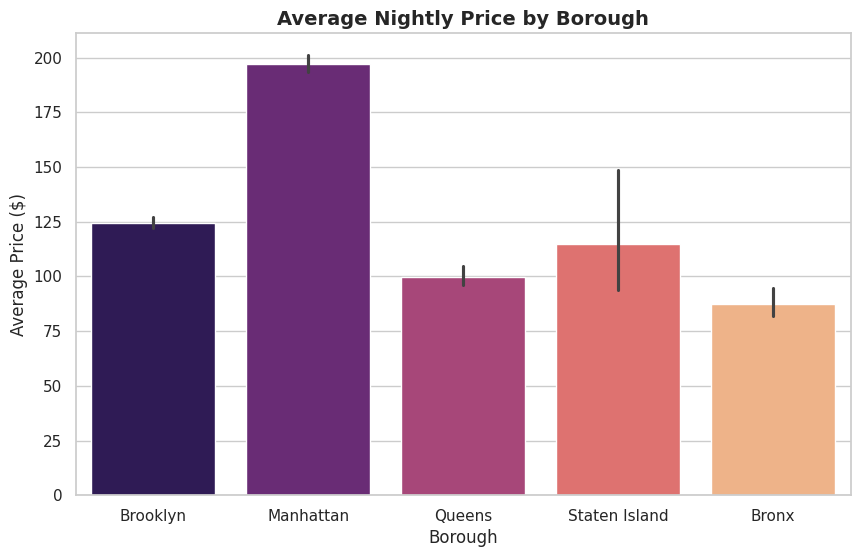

In [12]:
# 1. Bar Chart: Average Nightly Price by Borough
plt.figure(figsize=(10, 6))
sns.barplot(x='neighbourhood_group', y='price', data=df, estimator='mean', palette='magma')

plt.title('Average Nightly Price by Borough', fontsize=14, fontweight='bold')
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.show()


This bar chart clearly shows that Manhattan is the most expensive borough, nearly doubling the average price of the Bronx and Staten Island.

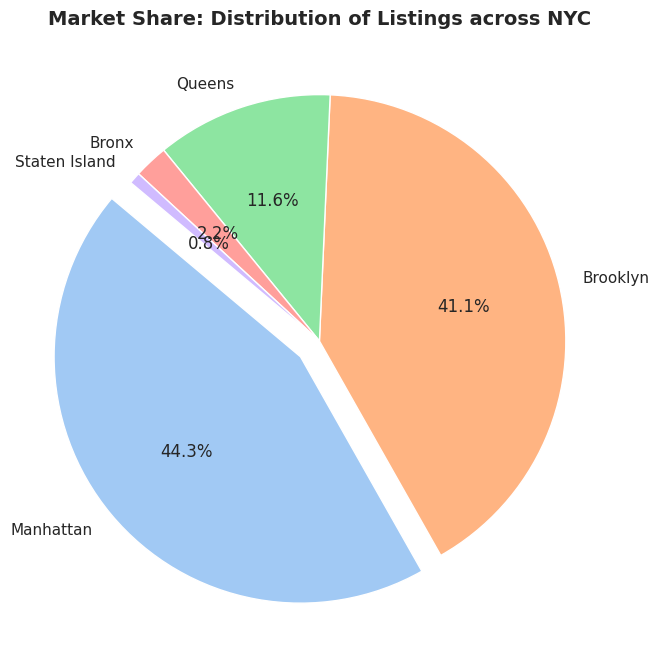

In [13]:
# 2. Pie Chart: Percentage of Total Listings
plt.figure(figsize=(8, 8))
df['neighbourhood_group'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=140,
    explode=(0.1, 0, 0, 0, 0) # This "pops out" the largest slice
)

plt.title('Market Share: Distribution of Listings across NYC', fontsize=14, fontweight='bold')
plt.ylabel('') # Removes the redundant 'count' label
plt.show()



While Manhattan is the most expensive, Brooklyn holds a massive 41.1% of the total market share, making it the most competitive area for hosts.

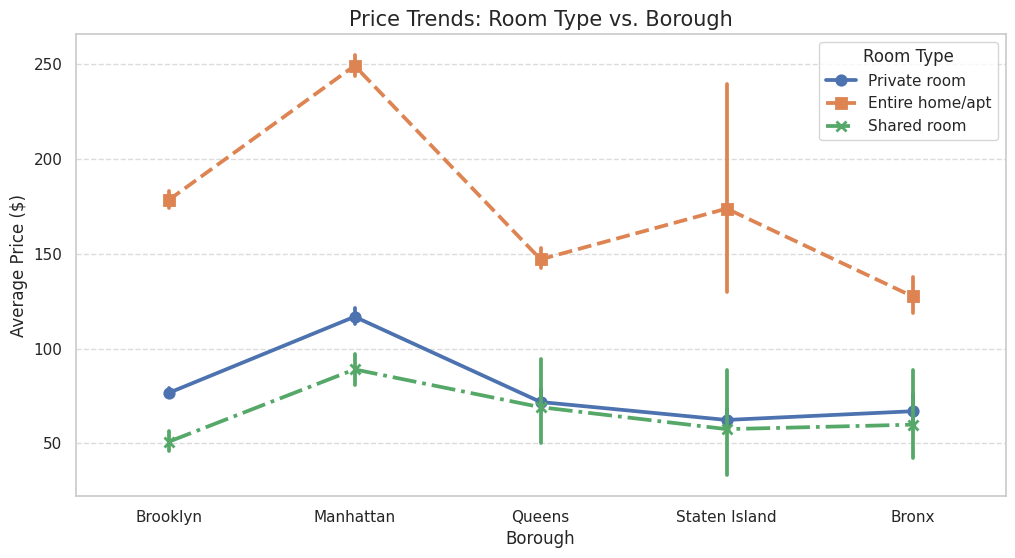

In [14]:
# Create a Line/Point Plot to show price trends by Room Type across Boroughs
plt.figure(figsize=(12, 6))

# We use sns.pointplot to create a "line" effect showing price trends
sns.pointplot(x='neighbourhood_group', y='price', hue='room_type', data=df,
              markers=["o", "s", "x"], linestyles=["-", "--", "-."])

plt.title('Price Trends: Room Type vs. Borough', fontsize=15)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.legend(title='Room Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Insight from Line Plot:**

The "Entire Home" Premium: The line for "Entire home/apt" sits significantly higher than the others across all boroughs, especially in Manhattan.

Stability in Private Rooms: The price for "Private rooms" is much more stable across Queens, Staten Island, and the Bronx compared to "Entire homes."

The Manhattan Gap: Notice the sharp "steepness" in the line when moving from Brooklyn to Manhattan; this visualizes the extreme price jump for entire apartments in the city center.

## Phase 5: Share (High-Level Insights)
After analyzing over 48,000 listings in NYC, these are the top three findings:
1. **The Price Leader:** **Manhattan** is the most expensive borough, with an average price nearly **double** that of the Bronx or Staten Island.
2. **The Volume King:** **Brooklyn** represents the largest market share (41.1% of all listings), indicating the highest demand and guest activity.
3. **The Revenue Driver:** "Entire Home/Apartment" listings command a massive price premium in all boroughs, particularly in Manhattan, where they peak.


## Phase 6: Act (Business Recommendations)
Based on the data, here is my strategic advice for the client:
*   **For Maximum ROI:** Invest in **Manhattan** properties, specifically focusing on **Entire Apartments**, as they yield the highest nightly revenue.
*   **For Lower Risk:** Invest in **Brooklyn**. The high volume of listings and reviews suggests a "proven" market with consistent occupancy rates.
*   **Further Exploration:** To refine this strategy, I recommend a secondary study on **Seasonality** (how prices change in Summer vs. Winter) and **Sentiment Analysis** of guest reviews to identify which amenities (WiFi, Pool, etc.) allow hosts to charge more.
